# 生物量特征提取 - 简化版本

使用本地数据进行生物量预测的简化实现

In [ ]:
# 导入必要的库
import numpy as np
import pandas as pd
import cv2
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib后端
%matplotlib inline

# 配置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['Noto Serif CJK SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print("导入完成")

导入完成


In [ ]:
# 数据路径设置
data_dir = "/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass"
train_dir = os.path.join(data_dir, "train")
csv_path = os.path.join(data_dir, "train.csv")

print(f"数据目录: {data_dir}")
print(f"训练图像目录: {train_dir}")
print(f"CSV文件: {csv_path}")

# 检查文件是否存在
print(f"目录存在: {os.path.exists(train_dir)}")
print(f"CSV存在: {os.path.exists(csv_path)}")

数据目录: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass
训练图像目录: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train
CSV文件: /home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train.csv
目录存在: True
CSV存在: True


In [ ]:
# 加载训练数据
if os.path.exists(csv_path):
    train = pd.read_csv(csv_path)
    print("数据集基本信息：")
    print(f"样本数量: {len(train)}")
    print(f"物种分布: {train['Species'].unique()}")
    print(f"数据列: {list(train.columns)}")
    
    # 显示前几行数据
    print("\n数据样本：")
    print(train.head())
    
    # 生物量统计
    print(f"\n生物量统计:")
    print(train['target'].describe())
else:
    print(f"CSV文件不存在: {csv_path}")

数据集基本信息：
样本数量: 1785
物种分布: ['Ryegrass_Clover' 'Lucerne' 'SubcloverDalkeith' 'Ryegrass'
 'Phalaris_Clover' 'SubcloverLosa' 'Clover' 'Fescue_CrumbWeed'
 'Phalaris_Ryegrass_Clover' 'Phalaris' 'WhiteClover' 'Fescue'
 'Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed'
 'Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass' 'Mixed']
数据列: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target']

数据样本：
                    sample_id              image_path Sampling_Date State  \
0  ID1011485656__Dry_Clover_g  train/ID1011485656.jpg      2015/9/4   Tas   
1    ID1011485656__Dry_Dead_g  train/ID1011485656.jpg      2015/9/4   Tas   
2   ID1011485656__Dry_Green_g  train/ID1011485656.jpg      2015/9/4   Tas   
3   ID1011485656__Dry_Total_g  train/ID1011485656.jpg      2015/9/4   Tas   
4         ID1011485656__GDM_g  train/ID1011485656.jpg      2015/9/4   Tas   

           Species  Pre_GSHH_NDVI  Height_Ave_cm   target_name   ta

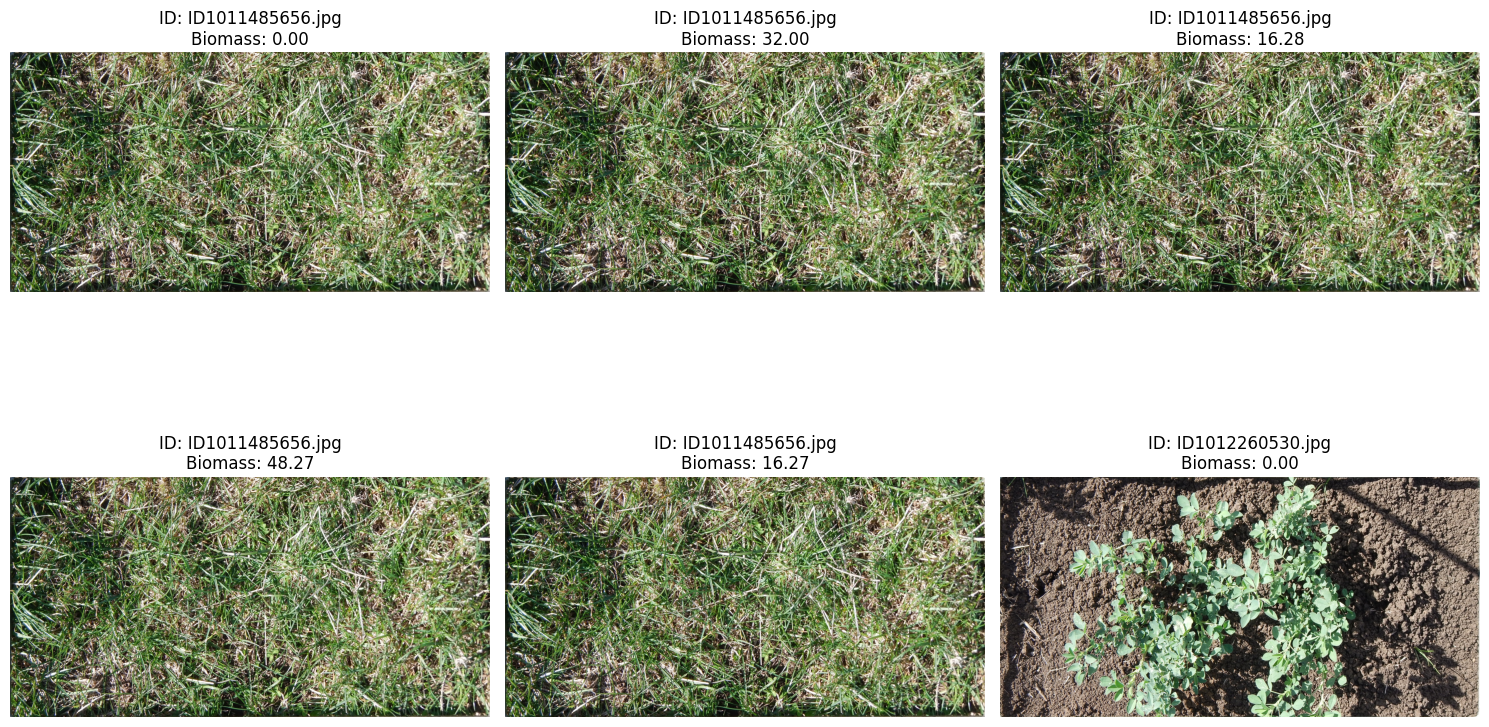

In [ ]:
# 显示示例图像
def plot_sample_images(train_df, data_dir, n_samples=6):
    """显示示例图像"""
    if len(train_df) == 0:
        print("没有数据可显示")
        return
    
    # 选择前n_samples个样本
    sample_df = train_df.head(n_samples)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        if i >= n_samples:
            break
        
        # 修复路径：CSV中的image_path是相对于data_dir的
        img_path = os.path.join(data_dir, row['image_path'])
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"ID: {os.path.basename(img_path)}\nBiomass: {row['target']:.2f}")
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f"Image not found\n{os.path.basename(img_path)}", 
                        ha='center', va='center', transform=axes[i].transAxes)
    
    plt.tight_layout()
    plt.show()

# 显示示例图像
if 'train' in locals():
    plot_sample_images(train, data_dir)

In [ ]:
# 简单的图像特征提取
def extract_image_features(image_path):
    """从图像中提取简单特征"""
    try:
        # 读取图像
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        # 转换为RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 调整大小
        img_resized = cv2.resize(img_rgb, (100, 100))
        
        # 提取颜色特征
        r, g, b = cv2.split(img_resized)
        features = [
            np.mean(r), np.std(r),
            np.mean(g), np.std(g),
            np.mean(b), np.std(b),
            np.mean(img_resized), np.std(img_resized)
        ]
        
        return features
    except Exception as e:
        print(f"处理图像 {image_path} 时出错: {e}")
        return None

# 提取所有图像的特征
if 'train' in locals():
    features_list = []
    valid_targets = []
    
    print("开始提取图像特征...")
    for idx, row in train.iterrows():
        # 修复路径：CSV中的image_path是相对于data_dir的
        img_path = os.path.join(data_dir, row['image_path'])
        features = extract_image_features(img_path)
        if features is not None:
            features_list.append(features)
            valid_targets.append(row['target'])
        
        if (idx + 1) % 100 == 0:
            print(f"已处理 {idx + 1}/{len(train)} 张图像")
    
    print(f"成功提取 {len(features_list)} 个样本的特征")
    
    # 转换为numpy数组
    if len(features_list) > 0:
        X = np.array(features_list)
        y = np.array(valid_targets)
        print(f"特征矩阵形状: {X.shape}")
        print(f"目标向量形状: {y.shape}")
    else:
        print("警告：没有成功提取任何特征！")
        X = np.array([])
        y = np.array([])

开始提取图像特征...


已处理 100/1785 张图像
已处理 200/1785 张图像
已处理 300/1785 张图像
已处理 400/1785 张图像
已处理 500/1785 张图像
已处理 600/1785 张图像
已处理 700/1785 张图像
已处理 800/1785 张图像
已处理 900/1785 张图像
已处理 1000/1785 张图像
已处理 1100/1785 张图像
已处理 1200/1785 张图像
已处理 1300/1785 张图像
已处理 1400/1785 张图像
已处理 1500/1785 张图像
已处理 1600/1785 张图像
已处理 1700/1785 张图像
成功提取 1785 个样本的特征
特征矩阵形状: (1785, 8)
目标向量形状: (1785,)


训练集大小: 1428
测试集大小: 357

训练随机森林回归器...


随机森林 - MSE: 600.8547, RMSE: 24.5123

训练线性回归模型...
线性回归 - MSE: 617.9020, RMSE: 24.8576


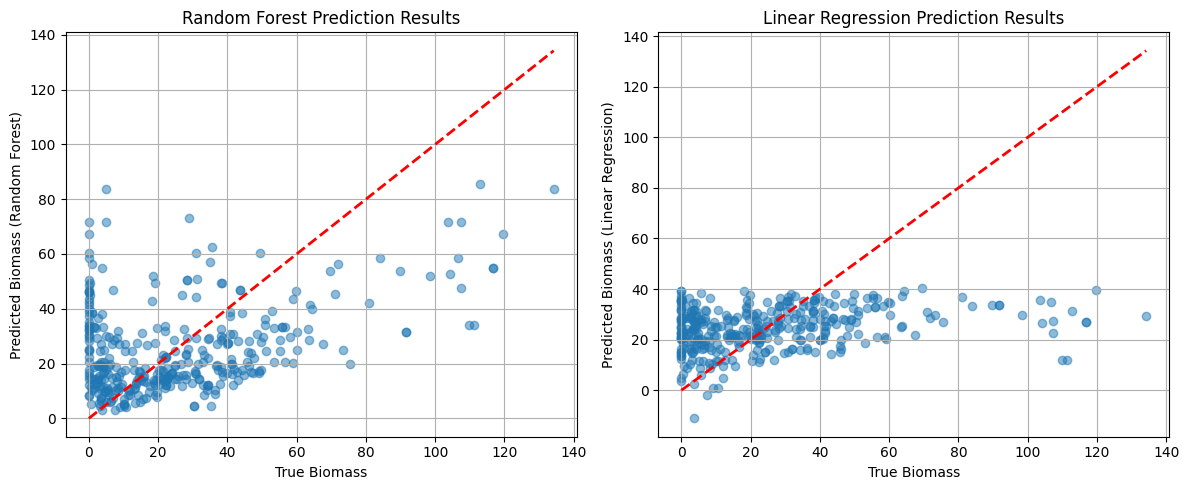


模型训练完成！


In [ ]:
# 训练简单模型
if 'X' in locals() and 'y' in locals():
    # 分割训练和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"训练集大小: {X_train.shape[0]}")
    print(f"测试集大小: {X_test.shape[0]}")
    
    # 训练随机森林模型
    print("\n训练随机森林回归器...")
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # 预测
    y_pred_rf = rf_model.predict(X_test)
    
    # 评估
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)
    
    print(f"随机森林 - MSE: {mse_rf:.4f}, RMSE: {rmse_rf:.4f}")
    
    # 训练线性回归作为对比
    print("\n训练线性回归模型...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    y_pred_lr = lr_model.predict(X_test)
    mse_lr = mean_squared_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    
    print(f"线性回归 - MSE: {mse_lr:.4f}, RMSE: {rmse_lr:.4f}")
    
    # 可视化结果
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_rf, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('True Biomass')
    plt.ylabel('Predicted Biomass (Random Forest)')
    plt.title('Random Forest Prediction Results')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred_lr, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('True Biomass')
    plt.ylabel('Predicted Biomass (Linear Regression)')
    plt.title('Linear Regression Prediction Results')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("\n模型训练完成！")